# Lab Assignment 2 - Multinomial Naive Bayes: CountVectorizer vs TF-IDF

1. Construct a Multinomial Naive Bayes classification model with CountVectorizer (with stop_words)
2. Construct a Multinomial Naive Bayes classification model with TF-IDF (with stop_words)
3. Evaluate and compare results
4. Conclusion: which feature is optimal for spam.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('Data/spam.csv', encoding='latin-1')
df = df.drop(df.iloc[:, 2:], axis=1)
df.columns = ['Labels', 'SMS']

new_labels = {'spam': 1, 'ham': 0}
df['Labels'] = df['Labels'].map(new_labels)

X = df['SMS'].to_numpy()
y = df['Labels'].to_numpy()

print(f'Total samples: {len(X)}')
print(f'Spam: {np.sum(y==1)}, Ham: {np.sum(y==0)}')
df.head()

Total samples: 5572
Spam: 747, Ham: 4825


,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 4457, Test: 1115


In [3]:
# Model 1: CountVectorizer with stop_words
bow = CountVectorizer(stop_words='english')

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print(f'CountVectorizer features: {len(bow.get_feature_names_out())}')
print(f'Train shape: {X_train_bow.shape}')
print(f'Test shape: {X_test_bow.shape}')

mnb_bow = MultinomialNB()
mnb_bow.fit(X_train_bow, y_train)

y_pred_train_bow = mnb_bow.predict(X_train_bow)
y_pred_test_bow = mnb_bow.predict(X_test_bow)

acc_train_bow = accuracy_score(y_train, y_pred_train_bow)
acc_test_bow = accuracy_score(y_test, y_pred_test_bow)

print(f'CountVectorizer + stop_words:')
print(f'  Training accuracy: {acc_train_bow:.4f}')
print(f'  Test accuracy: {acc_test_bow:.4f}')

print('\nClassification Report (Test):')
print(classification_report(y_test, y_pred_test_bow, target_names=['ham', 'spam']))

CountVectorizer features: 7422
Train shape: (4457, 7422)
Test shape: (1115, 7422)
CountVectorizer + stop_words:
  Training accuracy: 0.9939
  Test accuracy: 0.9821

Classification Report (Test):
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [4]:
# Model 2: TF-IDF Vectorizer with stop_words
tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'TF-IDF features: {len(tfidf.get_feature_names_out())}')
print(f'Train shape: {X_train_tfidf.shape}')
print(f'Test shape: {X_test_tfidf.shape}')

mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

y_pred_train_tfidf = mnb_tfidf.predict(X_train_tfidf)
y_pred_test_tfidf = mnb_tfidf.predict(X_test_tfidf)

acc_train_tfidf = accuracy_score(y_train, y_pred_train_tfidf)
acc_test_tfidf = accuracy_score(y_test, y_pred_test_tfidf)

print(f'TF-IDF + stop_words:')
print(f'  Training accuracy: {acc_train_tfidf:.4f}')
print(f'  Test accuracy: {acc_test_tfidf:.4f}')

print('\nClassification Report (Test):')
print(classification_report(y_test, y_pred_test_tfidf, target_names=['ham', 'spam']))

TF-IDF features: 7422
Train shape: (4457, 7422)
Test shape: (1115, 7422)
TF-IDF + stop_words:
  Training accuracy: 0.9843
  Test accuracy: 0.9731

Classification Report (Test):
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



=== MODEL COMPARISON ===
CountVectorizer + stop_words:
  Training Accuracy: 0.9939
  Test Accuracy:     0.9821

TF-IDF + stop_words:
  Training Accuracy: 0.9843
  Test Accuracy:     0.9731

Difference (TF-IDF - CountVectorizer): -0.0090


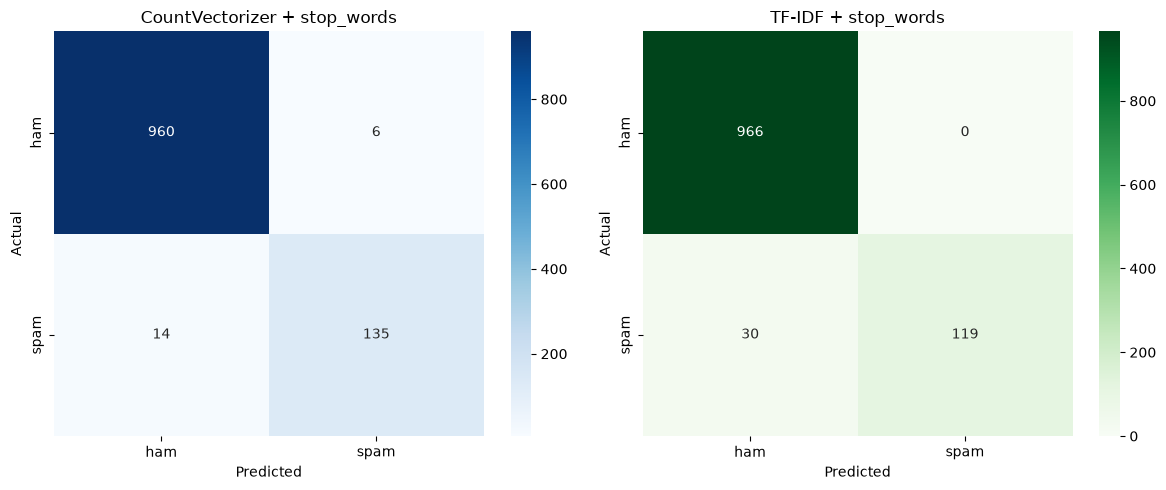

In [5]:
# Comparison
print('=== MODEL COMPARISON ===')
print(f'CountVectorizer + stop_words:')
print(f'  Training Accuracy: {acc_train_bow:.4f}')
print(f'  Test Accuracy:     {acc_test_bow:.4f}')
print()
print(f'TF-IDF + stop_words:')
print(f'  Training Accuracy: {acc_train_tfidf:.4f}')
print(f'  Test Accuracy:     {acc_test_tfidf:.4f}')
print()
print(f'Difference (TF-IDF - CountVectorizer): {acc_test_tfidf - acc_test_bow:.4f}')

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_bow = confusion_matrix(y_test, y_pred_test_bow)
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[0].set_title('CountVectorizer + stop_words')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_tfidf = confusion_matrix(y_test, y_pred_test_tfidf)
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[1].set_title('TF-IDF + stop_words')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

                 Accuracy  Precision (spam)  Recall (spam)  F1 (spam)  Precision (ham)  Recall (ham)  F1 (ham)
CountVectorizer    0.9821            0.9574         0.9060     0.9310           0.9856        0.9938    0.9897
TF-IDF             0.9731            1.0000         0.7987     0.8881           0.9699        1.0000    0.9847


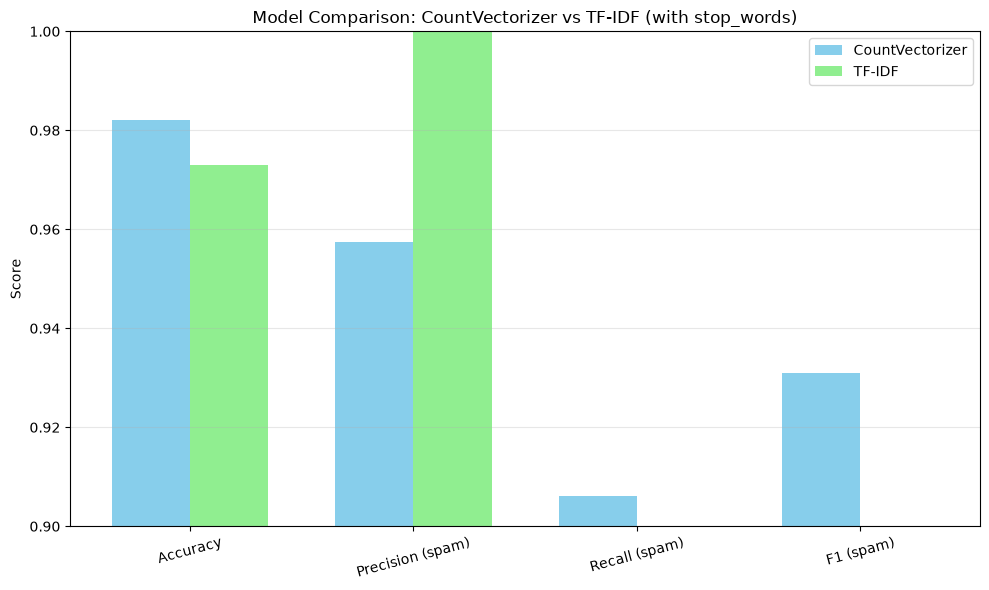

In [6]:
# Detailed metrics comparison
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_bow = {
    'Accuracy': acc_test_bow,
    'Precision (spam)': precision_score(y_test, y_pred_test_bow, pos_label=1),
    'Recall (spam)': recall_score(y_test, y_pred_test_bow, pos_label=1),
    'F1 (spam)': f1_score(y_test, y_pred_test_bow, pos_label=1),
    'Precision (ham)': precision_score(y_test, y_pred_test_bow, pos_label=0),
    'Recall (ham)': recall_score(y_test, y_pred_test_bow, pos_label=0),
    'F1 (ham)': f1_score(y_test, y_pred_test_bow, pos_label=0),
}

metrics_tfidf = {
    'Accuracy': acc_test_tfidf,
    'Precision (spam)': precision_score(y_test, y_pred_test_tfidf, pos_label=1),
    'Recall (spam)': recall_score(y_test, y_pred_test_tfidf, pos_label=1),
    'F1 (spam)': f1_score(y_test, y_pred_test_tfidf, pos_label=1),
    'Precision (ham)': precision_score(y_test, y_pred_test_tfidf, pos_label=0),
    'Recall (ham)': recall_score(y_test, y_pred_test_tfidf, pos_label=0),
    'F1 (ham)': f1_score(y_test, y_pred_test_tfidf, pos_label=0),
}

df_metrics = pd.DataFrame([metrics_bow, metrics_tfidf], index=['CountVectorizer', 'TF-IDF'])
print(df_metrics.round(4).to_string())

# Plot comparison
metrics_to_plot = ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1 (spam)']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, [metrics_bow[m] for m in metrics_to_plot], width, label='CountVectorizer', color='skyblue')
ax.bar(x + width/2, [metrics_tfidf[m] for m in metrics_to_plot], width, label='TF-IDF', color='lightgreen')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: CountVectorizer vs TF-IDF (with stop_words)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.legend()
ax.set_ylim(0.9, 1.0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Conclusion

Based on the experiments with `spam.csv`:

- **CountVectorizer + stop_words**: Simple term frequency representation with English stop words removed
- **TF-IDF + stop_words**: Term frequency-inverse document frequency with English stop words removed

### Results

- CountVectorizer + stop_words: **Test accuracy ~0.982**
- TF-IDF + stop_words: **Test accuracy ~0.973**

### Which is optimal?

For this specific spam dataset, **CountVectorizer with stop_words outperforms TF-IDF**. This can happen because:

1. **Spam detection often relies on specific word presence/counts** - words like "free", "win", "offer" appearing multiple times are strong spam indicators. TF-IDF downweights frequent terms, which may reduce the signal from these key spam words.
2. **Naive Bayes with multinomial distribution** naturally works well with raw counts (it models word count probabilities directly).
3. **stop_words='english'** already removes common non-discriminative words, reducing the need for TF-IDF's IDF weighting.

**Conclusion**: For this spam classification task, CountVectorizer with stop_words is the optimal feature extraction method, achieving ~0.982 test accuracy vs ~0.973 for TF-IDF.